In [1]:
import pandas as pd
from sklearn.mixture import GaussianMixture
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import hdbscan
from sklearn.preprocessing import StandardScaler
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
import numpy as np
from hmmlearn.hmm import GaussianHMM
import hdbscan
import plotly.graph_objects as go



In [2]:
with open('../../data/nifty_ts2vec_embeddings.pkl', 'rb') as f:
    df = pickle.load(f)

In [3]:
df = df.loc["2020-04-01":]

In [4]:
embeddings = df.drop("Close", axis=1)
embeddings

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
Date,,,,,,,,,,,,,,,,,,,,,
2020-04-01,0.031711,0.034374,0.078974,0.0,0.018118,0.000000,0.0,0.009533,0.079131,0.084830,...,0.010104,0.007383,0.016423,0.036842,0.019440,0.088125,0.000000,0.128857,0.128877,0.137900
2020-04-03,0.034624,0.044971,0.072362,0.0,0.022477,0.000086,0.0,0.013181,0.074632,0.080595,...,0.007038,0.007630,0.014312,0.032914,0.019244,0.101760,0.000000,0.125461,0.126979,0.146261
2020-04-07,0.038164,0.054827,0.065434,0.0,0.024082,0.001839,0.0,0.014690,0.067445,0.076076,...,0.005505,0.008187,0.012238,0.029921,0.019711,0.111837,0.000999,0.120082,0.126020,0.153475
2020-04-08,0.040825,0.064055,0.056131,0.0,0.022151,0.003792,0.0,0.015702,0.057390,0.074257,...,0.005059,0.008970,0.009718,0.029555,0.019959,0.119358,0.003654,0.113508,0.125524,0.159206
2020-04-09,0.041757,0.071762,0.045957,0.0,0.019385,0.006160,0.0,0.014906,0.045184,0.072622,...,0.005510,0.009923,0.007485,0.029136,0.020629,0.122364,0.007998,0.104609,0.126620,0.161618
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-12,0.039898,0.000000,0.000000,0.0,0.037175,0.007709,0.0,0.198886,0.000000,0.000691,...,0.027305,0.021603,0.035282,0.060062,0.045333,0.006579,0.000000,0.000000,0.128279,0.021880
2025-09-15,0.041106,0.000000,0.000000,0.0,0.040144,0.007308,0.0,0.199363,0.000000,0.001671,...,0.029627,0.021746,0.035920,0.062121,0.048278,0.007309,0.000000,0.000000,0.124305,0.022726
2025-09-16,0.041802,0.000000,0.000000,0.0,0.042458,0.007110,0.0,0.198903,0.000000,0.002719,...,0.031468,0.024219,0.036828,0.063576,0.050335,0.006806,0.000000,0.000000,0.120679,0.022671


In [5]:
30*0.6

18.0

In [13]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=25,
    min_samples=6,
    metric="euclidean",
    cluster_selection_method="leaf",
    cluster_selection_epsilon = 0,   
    allow_single_cluster=False,
    prediction_data=True
)
labels = clusterer.fit_predict(embeddings)

In [14]:
df["HDBSCAN_Labels"] = labels

In [15]:
df["HDBSCAN_Labels"].value_counts(normalize=True)

HDBSCAN_Labels
-1     0.215078
 5     0.088692
 1     0.069475
 4     0.058389
 11    0.054693
 14    0.050259
 13    0.045085
 2     0.042129
 0     0.040650
 3     0.036955
 12    0.034738
 19    0.034738
 7     0.033999
 9     0.033259
 18    0.032520
 17    0.025129
 15    0.022173
 8     0.022173
 6     0.021434
 10    0.019217
 16    0.019217
Name: proportion, dtype: float64

In [9]:
df["HDBSCAN_Labels"].value_counts(normalize=True).head().to_clipboard()

In [16]:
df["HDBSCAN_Labels"].nunique() #51

21

In [17]:
fig = go.Figure()

# Scatter per regime/cluster
for c in sorted(df["HDBSCAN_Labels"].dropna().unique()):
    mask = df["HDBSCAN_Labels"] == c
    fig.add_trace(
        go.Scatter(
            x=df.index[mask],
            y=df.loc[mask, "Close"],
            mode="markers",
            name=f"Regime {c}",
            marker=dict(size=6),
        )
    )

# Underlay full close series
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Close"],
        mode="lines",
        name="Close",
        line=dict(color="black", width=1),
        opacity=0.6,
    )
)

fig.update_layout(
    title="Nifty 50 Regimes (Clustering)",
    # width=1400,
    height=820,
    legend_title_text="Regime",
    xaxis_title="Date",
    yaxis_title="Close",
    template="plotly_white",
)

fig.show()

In [18]:
# plt.figure(figsize=(25,6))

# for c in df['HDBSCAN_Labels'].dropna().unique():
#     mask = df['HDBSCAN_Labels'] == c
#     plt.scatter(df.index[mask], df['Close'][mask], label=f"Regime {c}", s=10)
# plt.plot(df.index, df['Close'], color='black', linewidth=0.5, alpha=0.6)
# plt.title("Nifty 50 Regimes (Clustering)")
# plt.legend()
# plt.show()

In [19]:
hdb_labels = df["HDBSCAN_Labels"].values

In [20]:
from sklearn.metrics import pairwise_distances_argmin

# Ensure we operate on numpy arrays (pairwise_distances_argmin expects array-like)
X = embeddings.to_numpy() if hasattr(embeddings, "to_numpy") else np.asarray(embeddings)
labels = np.asarray(hdb_labels).copy()

# centroids from non-noise clusters
clusters = np.unique(labels[labels >= 0])

# If everything is noise (or there are no points), we can't reassign
if clusters.size == 0:
    print("No non-noise clusters found; leaving labels unchanged.")
else:
    centroids = np.vstack([X[labels == k].mean(axis=0) for k in clusters])

    # reassign noise (if any) to nearest centroid
    noise_idx = np.where(labels == -1)[0]
    if noise_idx.size == 0:
        print("No noise points to reassign.")
    else:
        nearest = pairwise_distances_argmin(X[noise_idx], centroids)
        labels[noise_idx] = clusters[nearest]

In [21]:
np.mean(labels == -1)

0.0

In [22]:
len(centroids)

20

In [23]:
from sklearn.cluster import AgglomerativeClustering

K0 = 15  # start here

agg = AgglomerativeClustering(
    n_clusters=K0,
    linkage="ward"
)

proto_labels = agg.fit_predict(centroids)

In [24]:
proto_labels

array([ 4,  2,  9,  3, 14,  8, 11, 12,  2, 13,  6, 10,  3,  4,  7,  5,  1,
        1,  0,  0])

In [25]:
proto_state = np.zeros_like(labels)
cluster_ids = np.unique(labels)

for cid, p in zip(cluster_ids, proto_labels):
    proto_state[labels == cid] = p

In [26]:
np.unique(proto_state)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

In [27]:
def init_from_micro_regimes(X, labels, min_points=20):
    states = np.unique(labels)
    means, covs = [], []

    for k in states:
        pts = X[labels == k]
        if len(pts) < min_points:
            continue
        means.append(pts.mean(axis=0))
        covs.append(
            np.cov(pts.T) + 1e-6 * np.eye(X.shape[1])
        )

    return np.array(means), np.array(covs)


def full_to_diag_cov(covs):
    """
    covs: (K, D, D)
    returns: (K, D)
    """
    return np.array([
        np.diag(cov) for cov in covs
    ])


def init_from_proto_states_diag(X, proto_state, min_points=50):
    states = np.unique(proto_state)
    means, diag_covs = [], []

    for k in states:
        pts = X[proto_state == k]
        if len(pts) < min_points:
            continue

        mu = pts.mean(axis=0)
        cov = np.cov(pts.T)

        # strong regularization for stability
        cov += 1e-3 * np.eye(X.shape[1])

        means.append(mu)
        diag_covs.append(np.diag(cov))

    return np.array(means), np.array(diag_covs)

In [28]:
init_means, init_covs = init_from_proto_states_diag(
    embeddings, proto_state
)

K = len(init_means)
print("HMM init states:", K)

HMM init states: 14


In [29]:
from hmmlearn.hmm import GaussianHMM

def sticky_transition(K, kappa=70, base=1.0):
    A = np.full((K, K), base)
    np.fill_diagonal(A, base + kappa)
    return A / A.sum(axis=1, keepdims=True)


model = GaussianHMM(
    n_components=K,
    covariance_type="diag",   
    n_iter=1500,
    tol=1e-3,
    init_params=""
)

model.startprob_ = np.ones(K) / K
model.transmat_ = sticky_transition(K)
model.means_ = init_means
model.covars_ = init_covs

model.fit(embeddings)

Model is not converging.  Current: 213214.09397872828 is not greater than 213214.13026142953. Delta is -0.03628270124318078


,n_components,14
,covariance_type,'diag'
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1
,algorithm,'viterbi'
,random_state,None


In [30]:
# save the model
with open('../../models/nifty_hmm_model.pkl', 'wb') as f:
    pickle.dump(model, f)

In [31]:
post = model.predict_proba(embeddings)
state_mass = post.mean(axis=0)

print("Effective states:",
      np.sum(state_mass > 0.01))

Effective states: 14


In [32]:
len(state_mass)

14

In [33]:
state_mass

array([0.07889768, 0.05695882, 0.11651604, 0.08564278, 0.08708302,
       0.04635336, 0.05914344, 0.09940842, 0.07530053, 0.06210277,
       0.05495488, 0.07017799, 0.04136746, 0.0660928 ])

In [34]:
keep = state_mass > 0.03
posteriors = post[:, keep]

In [35]:
posteriors.shape

(1353, 14)

In [36]:
viterbi = model.predict(embeddings)
np.mean(viterbi[1:] == viterbi[:-1])

0.9822485207100592

In [37]:
len(viterbi)

1353

In [38]:
df["HMM_Labels"] = viterbi

In [39]:
df["HMM_Labels"].value_counts()

HMM_Labels
2     158
7     134
4     118
3     116
0     107
8     102
11     95
13     89
9      84
6      80
1      77
10     74
5      63
12     56
Name: count, dtype: int64

In [40]:
fig = go.Figure()

# Scatter per regime/cluster
for c in sorted(df["HMM_Labels"].dropna().unique()):
    mask = df["HMM_Labels"] == c
    fig.add_trace(
        go.Scatter(
            x=df.index[mask],
            y=df.loc[mask, "Close"],
            mode="markers",
            name=f"Regime {c}",
            marker=dict(size=6),
        )
    )

# Underlay full close series
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Close"],
        mode="lines",
        name="Close",
        line=dict(color="black", width=1),
        opacity=0.6,
    )
)

fig.update_layout(
    title="Nifty 50 Regimes (Clustering)",
    # width=1400,
    height=820,
    legend_title_text="Regime",
    xaxis_title="Date",
    yaxis_title="Close",
    template="plotly_white",
)

fig.show()

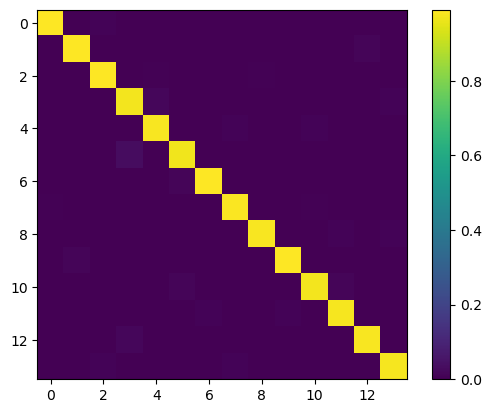

In [41]:
plt.imshow(model.transmat_, cmap="viridis")
plt.colorbar()

In [42]:
def compute_state_signatures(
    states,
    returns,
    volatility,
    price,
    lookback_weight=None
):
    """
    returns DataFrame of shape (K, features)
    """

    K = int(states.max()) + 1
    sig = []
    print("Computing signatures for", K, "states")

    T = len(states)
    weights = (
        np.exp(-np.arange(T)[::-1] / lookback_weight)
        if lookback_weight is not None
        else np.ones(T)
    )

    for k in range(K):
        print(f"State {k}: ", end="")
        idx = states == k
        if idx.sum() < 30:
            print("Ignoring ", idx)
            continue

        w = weights[idx]

        sig.append({
            "state": k,
            "freq": idx.mean(),
            "mean_return": np.average(returns[idx], weights=w),
            "volatility": np.average(volatility[idx], weights=w),
            "trend": np.polyfit(
                np.arange(idx.sum()),
                price[idx],
                1
            )[0],
            "drawdown": np.min(
                price[idx] / np.maximum.accumulate(price[idx]) - 1
            ),
        })

    return pd.DataFrame(sig).set_index("state")

In [43]:
# X_emb        # ts2vec embeddings (T, D)
# returns      # daily log returns (T,)
# volatility   # rolling vol (T,)
# price        # index price (T,)
# states       # HMM state sequence (T,)
# posteriors   # HMM posteriors (T, K)

returns = np.log(df["Close"] / df["Close"].shift(1)).fillna(0).values
volatility = df["Close"].rolling(20).std().bfill().values
price = df["Close"].values
states = viterbi
state_df = compute_state_signatures(
    states, returns, volatility, price, lookback_weight=100
)


Computing signatures for 14 states
State 0: State 1: State 2: State 3: State 4: State 5: State 6: State 7: State 8: State 9: State 10: State 11: State 12: State 13: 

In [44]:

state_df.sort_values("freq", ascending=False)

,freq,mean_return,volatility,trend,drawdown
state,,,,,
2,0.116778,0.001182,296.045482,43.153648,-0.084689
7,0.099039,0.000096,350.377928,43.139643,-0.108431
4,0.087214,0.000814,220.707631,77.560855,-0.069585
3,0.085735,-0.000122,244.835394,104.249945,-0.053459
0,0.079084,0.000634,230.294696,2.043308,-0.066119
8,0.075388,0.001449,304.617966,35.650786,-0.059294
11,0.070214,-0.000768,419.392758,117.398272,-0.125807
13,0.065780,-0.001058,362.176745,81.927878,-0.102355
9,0.062084,0.001689,194.421577,16.787396,-0.072294


In [45]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

features = [
    "mean_return",
    "volatility",
    "trend",
    "drawdown",
]

X_state = StandardScaler().fit_transform(state_df[features])

clusterer = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)

state_df["macro_regime"] = clusterer.fit_predict(X_state)

In [46]:
state_to_macro = state_df["macro_regime"].to_dict()
macro_states = np.array([state_to_macro[s] for s in states])

In [47]:
macro_summary = (
    state_df
    .groupby("macro_regime")
    .agg({
        "mean_return": "mean",
        "volatility": "mean",
        "trend": "mean",
        "drawdown": "mean",
    })
)

In [48]:
labels = {}

ret_rank = macro_summary["mean_return"].rank()
vol_rank = macro_summary["volatility"].rank()
dd_rank  = macro_summary["drawdown"].rank()

for k in macro_summary.index:
    if ret_rank[k] == ret_rank.max() and vol_rank[k] <= 3:
        labels[k] = "Strong Bull"

    elif ret_rank[k] >= 4:
        labels[k] = "Bull"

    elif ret_rank[k] <= 2 and dd_rank[k] <= 2:
        labels[k] = "Bear"

    elif vol_rank[k] == vol_rank.max():
        labels[k] = "High Volatility"

    else:
        labels[k] = "Sideways / Transition"

In [49]:
macro_summary["label"] = macro_summary.index.map(labels)

In [50]:
macro_summary

,mean_return,volatility,trend,drawdown,label
macro_regime,,,,,
0,-0.000577,377.315810,80.821931,-0.112198,Bear
1,0.001374,272.591500,40.770095,-0.070740,Bull
2,-0.000128,230.803978,130.105724,-0.052134,Sideways / Transition
3,0.001636,518.546481,138.406734,-0.133545,Bull
4,0.000418,250.712650,-2.619601,-0.066305,Sideways / Transition


In [51]:
bull_strength = {}

for k, row in macro_summary.iterrows():
    if row["label"] == "Strong Bull":
        bull_strength[k] = 1.0
    elif row["label"] == "Bull":
        bull_strength[k] = 0.75
    elif row["label"] == "Sideways / Transition":
        bull_strength[k] = 0.55
    elif row["label"] == "High Volatility":
        bull_strength[k] = 0.2
    else:  # Bear
        bull_strength[k] = 0.0

In [52]:
def rolling_percentile(x, window=252):
    out = np.full_like(x, np.nan)
    for i in range(window, len(x)):
        out[i] = (
            np.sum(x[i-window:i] <= x[i]) / window
        )
    return out

In [53]:
state_to_macro

{0: 4,
 1: 1,
 2: 1,
 3: 2,
 4: 1,
 5: 2,
 6: 1,
 7: 0,
 8: 1,
 9: 1,
 10: 3,
 11: 0,
 12: 4,
 13: 0}

In [54]:
state_bull_strength = {
    s: bull_strength[state_to_macro[s]]
    for s in state_to_macro
}
state_bull_strength

{0: 0.55,
 1: 0.75,
 2: 0.75,
 3: 0.55,
 4: 0.75,
 5: 0.55,
 6: 0.75,
 7: 0.0,
 8: 0.75,
 9: 0.75,
 10: 0.75,
 11: 0.0,
 12: 0.55,
 13: 0.0}

In [55]:
def bull_confidence_from_posteriors(posteriors, state_bull_strength):
    """
    posteriors: (T, K)
    returns: (T,) bull confidence in [0, 1]
    """
    weights = np.array([
        state_bull_strength[k] for k in range(posteriors.shape[1])
    ])
    return posteriors @ weights

In [56]:
posteriors

array([[0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
        1.00000000e+000, 0.00000000e+000, 2.04189708e-223],
       [0.00000000e+000, 0.00000000e+000, 2.04189708e-223, ...,
        1.00000000e+000, 0.00000000e+000, 4.16511377e-269],
       ...,
       [6.82473419e-167, 0.00000000e+000, 5.38299950e-166, ...,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [3.98062173e-167, 0.00000000e+000, 6.82473419e-167, ...,
        0.00000000e+000, 0.00000000e+000, 5.58294180e-322],
       [1.75176125e-110, 0.00000000e+000, 3.98061715e-167, ...,
        6.71013729e-291, 0.00000000e+000, 3.71647613e-274]])

In [57]:
bull_conf = bull_confidence_from_posteriors(
    posteriors,
    state_bull_strength
)
bull_conf

array([7.50000000e-01, 7.68008215e-37, 2.79196839e-76, ...,
       7.50000000e-01, 7.50000000e-01, 7.50000000e-01])

In [58]:
# plot bull confidence over time
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=bull_conf,
        mode="lines",
        name="Bull Confidence",
        line=dict(color="blue", width=2),
    )
)
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Close"],
        mode="lines",
        name="Close",
        line=dict(color="black", width=1),
        opacity=0.6,
        yaxis="y2"
    )
)
fig.update_layout(
    title="Nifty 50 Bull Confidence Over Time",
    xaxis_title="Date",
    yaxis_title="Bull Confidence",
    yaxis2=dict(
        title="Close Price",
        overlaying="y",
        side="right"
    ),
    template="plotly_white"
)
fig.show()

In [59]:
def smooth_series(x, half_life=20):
    alpha = 1 - np.exp(np.log(0.5) / half_life)
    y = np.zeros_like(x)
    y[0] = x[0]
    for t in range(1, len(x)):
        y[t] = alpha * x[t] + (1 - alpha) * y[t-1]
    return y

bull_conf_smooth = smooth_series(bull_conf, half_life=20)
bull_conf_rel = rolling_percentile(bull_conf_smooth, 252)

In [60]:
# plot bull_conf_smooth over time
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=bull_conf_smooth,
        mode="lines",
        name="Smoothed Bull Confidence",
        line=dict(color="blue", width=2),
    )
)
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=bull_conf_rel,
        mode="lines",
        name="Relative Bull Confidence",
        line=dict(color="green", width=2, dash="dash"),
    )
)
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Close"],
        mode="lines",
        name="Close",
        line=dict(color="black", width=1),
        opacity=0.6,
        yaxis="y2"
    )
)
fig.update_layout(
    title="Nifty 50 Smoothed Bull Confidence Over Time",
    xaxis_title="Date",
    yaxis_title="Smoothed Bull Confidence",
    yaxis2=dict(
        title="Close Price",
        overlaying="y",
        side="right"
    ),
    template="plotly_white"
)
fig.show()

In [61]:
bull_momentum = bull_conf_smooth - smooth_series(
    bull_conf_smooth, half_life=60
)

In [62]:
# plot bull momentum over time
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=bull_momentum,
        mode="lines",
        name="Bull Momentum",
        line=dict(color="red", width=2),
    )
)
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Close"],
        mode="lines",
        name="Close",
        line=dict(color="black", width=1),
        opacity=0.6,
        yaxis="y2"
    )
)
fig.update_layout(
    title="Nifty 50 Bull Momentum Over Time",
    xaxis_title="Date",
    yaxis_title="Bull Momentum",
    yaxis2=dict(
        title="Close Price",
        overlaying="y",
        side="right"
    ),
    template="plotly_white"
)
fig.show()

In [63]:
from scipy.stats import multivariate_normal

def hmm_filter_step(x_t, prev_gamma, model):
    K = model.n_components

    # emission likelihoods
    lik = np.zeros(K)
    for k in range(K):
        lik[k] = multivariate_normal.pdf(
            x_t,
            mean=model.means_[k],
            cov=model.covars_[k]
        )

    # predict
    pred = prev_gamma @ model.transmat_

    # update
    gamma = pred * lik
    gamma /= gamma.sum()

    return gamma

In [65]:
gamma_t = posteriors[-1]
gamma_t

array([1.75176125e-110, 0.00000000e+000, 3.98061715e-167, 1.63943003e-308,
       1.00000000e+000, 8.23428214e-233, 0.00000000e+000, 9.96268504e-044,
       7.50873911e-209, 0.00000000e+000, 2.89824759e-118, 6.71013729e-291,
       0.00000000e+000, 3.71647613e-274])

In [ ]:
gamma_t = posteriors[-1]

bull_conf_live = []

for x_t in new_embeddings:   # streaming TS2Vec embeddings
    gamma_t = hmm_filter_step(x_t, gamma_t, model)

    bc = sum(
        gamma_t[k] * state_bull_strength[k]
        for k in range(len(gamma_t))
    )
    bull_conf_live.append(bc)

In [ ]:
bull_conf_live_smooth = smooth_series(
    np.array(bull_conf_live),
    half_life=20
)

In [60]:
# bull_momentum, bull_conf_smooth, df["Close"]

cdf=pd.DataFrame({
    "bull_momentum": bull_momentum,
    "bull_confidence": bull_conf_smooth,
    "close": df["Close"]
})

In [61]:
cdf

,bull_momentum,bull_confidence,close
Date,,,
2020-04-01 00:00:00+05:30,0.000000,1.000000,8253.799805
2020-04-03 00:00:00+05:30,0.000000,1.000000,8083.799805
2020-04-07 00:00:00+05:30,0.000000,1.000000,8792.200195
2020-04-08 00:00:00+05:30,0.000000,1.000000,8748.750000
2020-04-09 00:00:00+05:30,0.000000,1.000000,9111.900391
...,...,...,...
2025-09-12 00:00:00+05:30,0.101317,0.401985,25114.000000
2025-09-15 00:00:00+05:30,0.100086,0.401917,25069.199219
2025-09-16 00:00:00+05:30,0.098872,0.401852,25239.099609


In [64]:
cdf.reset_index().describe().to_clipboard()